<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/currency_comibined_trade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

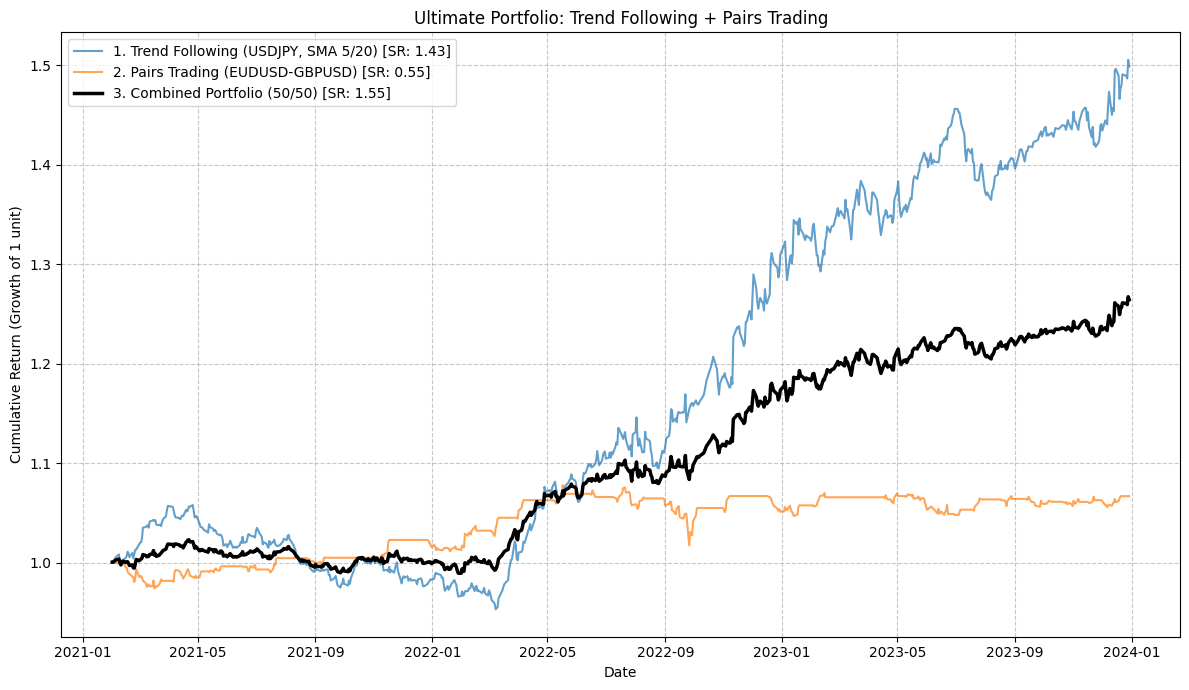

--- ポートフォリオの統計情報 ---
戦略間の相関係数: -0.035
組み合わせ戦略の年率シャープレシオ: 1.547
最終リターン: 26.44%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# データの準備
if 'df' not in locals():
    df = pd.read_csv('/content/通貨データセット1.csv', index_col=0, parse_dates=True)
    df = df.select_dtypes(include=[np.number])

returns_df = np.log(df / df.shift(1)).dropna()
tc = 0.0005 # 取引コスト

# --- 1. 最適化トレンドフォロー戦略 (USDJPY: SMA 5日 & 20日) ---
asset_tf = 'USDJPY'
price_tf = df[asset_tf]
sma_short = price_tf.rolling(window=5).mean()
sma_long = price_tf.rolling(window=20).mean()

signals_tf_vals = np.where(sma_short > sma_long, 1, -1)
signals_tf = pd.Series(signals_tf_vals, index=price_tf.index)

cost_tf = signals_tf.diff().abs() * tc
gross_ret_tf = signals_tf.shift(1) * returns_df[asset_tf]
ret_tf = (gross_ret_tf - cost_tf.shift(1)).fillna(0)

# --- 2. ペアトレード戦略 (EUDUSD & GBPUSD: Zスコア 2.0 エントリー) ---
asset1_pt, asset2_pt = 'EUDUSD', 'GBPUSD'
y = np.log(df[asset1_pt])
x = np.log(df[asset2_pt])

x_with_const = sm.add_constant(x)
model = sm.OLS(y, x_with_const).fit()
beta = model.params.iloc[1]

spread = y - beta * x
window_pt = 20
rolling_mean = spread.rolling(window=window_pt).mean()
rolling_std = spread.rolling(window=window_pt).std()
z_score = (spread - rolling_mean) / rolling_std

z_vals = z_score.fillna(0).values
sig_vals_pt = np.zeros(len(z_vals))
pos = 0
entry_z = 2.0
for i in range(1, len(z_vals)):
    if z_vals[i-1] > entry_z: pos = -1
    elif z_vals[i-1] < -entry_z: pos = 1
    elif pos == -1 and z_vals[i-1] <= 0: pos = 0
    elif pos == 1 and z_vals[i-1] >= 0: pos = 0
    sig_vals_pt[i] = pos

signals_pt = pd.Series(sig_vals_pt, index=z_score.index)
weight1_pt = signals_pt
weight2_pt = -beta * signals_pt

gross_ret_pt = weight1_pt.shift(1) * returns_df[asset1_pt] + weight2_pt.shift(1) * returns_df[asset2_pt]
cost_pt = (weight1_pt.diff().abs() + weight2_pt.diff().abs()) * tc
ret_pt = (gross_ret_pt - cost_pt).fillna(0)

# --- 3. 組み合わせ戦略 (50% / 50% 配分) ---
ret_combined = 0.5 * ret_tf + 0.5 * ret_pt

# データ期間の調整 (SMA 20日の欠損を除外)
valid_idx = ret_combined.index[20:]
ret_tf_eval = ret_tf.loc[valid_idx]
ret_pt_eval = ret_pt.loc[valid_idx]
ret_combined_eval = ret_combined.loc[valid_idx]

# --- パフォーマンス評価 ---
def calc_stats(ret_series):
    cum_ret = np.exp(ret_series.cumsum())
    sr = (ret_series.mean() / ret_series.std()) * np.sqrt(252) if ret_series.std() != 0 else 0
    return cum_ret, sr

cum_tf, sr_tf = calc_stats(ret_tf_eval)
cum_pt, sr_pt = calc_stats(ret_pt_eval)
cum_cmb, sr_cmb = calc_stats(ret_combined_eval)

# グラフ描画
plt.figure(figsize=(12, 7))
plt.plot(cum_tf, label=f'1. Trend Following ({asset_tf}, SMA 5/20) [SR: {sr_tf:.2f}]', alpha=0.7)
plt.plot(cum_pt, label=f'2. Pairs Trading ({asset1_pt}-{asset2_pt}) [SR: {sr_pt:.2f}]', alpha=0.7)
plt.plot(cum_cmb, label=f'3. Combined Portfolio (50/50) [SR: {sr_cmb:.2f}]', color='black', linewidth=2.5)

plt.title('Ultimate Portfolio: Trend Following + Pairs Trading')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Growth of 1 unit)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 相関の確認
corr = ret_tf_eval.corr(ret_pt_eval)
print(f"--- ポートフォリオの統計情報 ---")
print(f"戦略間の相関係数: {corr:.3f}")
print(f"組み合わせ戦略の年率シャープレシオ: {sr_cmb:.3f}")
print(f"最終リターン: {(cum_cmb.iloc[-1] - 1)*100:.2f}%")


--- 全通貨の移動平均クロスオーバー最適化を開始 (少々時間がかかります) ---


,Asset,Best Short SMA,Best Long SMA,Max Sharpe Ratio
0,USDJPY,5,20,1.349153
1,EUDUSD,10,160,0.983719
2,GBPUSD,10,60,0.778587
3,EURGBP,40,160,0.506759
4,AUDEUR,5,150,0.400783
5,AUDUSD,20,140,0.377286
6,EURJPY,35,40,0.357715
7,AUDJPY,10,20,0.277446


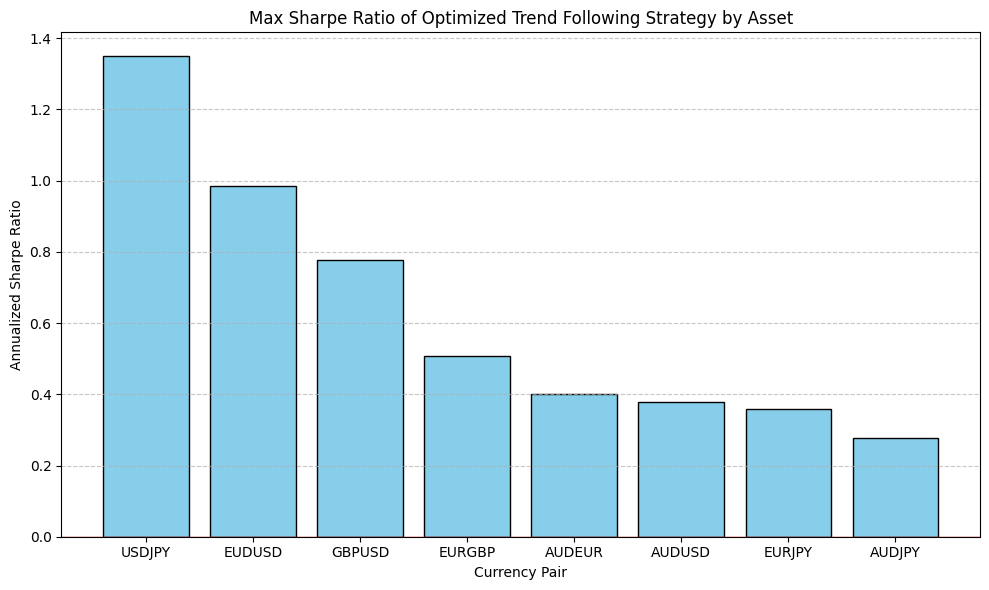

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# データの準備
if 'df' not in locals():
    df = pd.read_csv('/content/通貨データセット1.csv', index_col=0, parse_dates=True)
    df = df.select_dtypes(include=[np.number])

returns_df = np.log(df / df.shift(1)).dropna()
tc = 0.0005 # 取引コスト

# パラメータの探索範囲
short_windows = range(5, 55, 5)
long_windows = range(20, 210, 10)

summary_results = []

print("--- 全通貨の移動平均クロスオーバー最適化を開始 (少々時間がかかります) ---")
for asset in df.columns:
    price = df[asset]
    actual_returns = returns_df[asset]

    best_sr = -np.inf
    best_sw = None
    best_lw = None

    for sw in short_windows:
        for lw in long_windows:
            if sw >= lw:
                continue

            sma_short = price.rolling(window=sw).mean()
            sma_long = price.rolling(window=lw).mean()

            # シグナル: 短期 > 長期 で 1 (買い)、それ以外は -1 (売り)
            signals = np.where(sma_short > sma_long, 1, -1)
            signals = pd.Series(signals, index=price.index)

            # ポジションの変更にかかるコスト
            turnover = signals.diff().abs()
            cost = turnover * tc

            # リターンの計算
            gross_returns = signals.shift(1) * actual_returns
            strat_returns = (gross_returns - cost.shift(1)).dropna()

            if strat_returns.std() != 0:
                sr = (strat_returns.mean() / strat_returns.std()) * np.sqrt(252)
            else:
                sr = 0.0

            if sr > best_sr:
                best_sr = sr
                best_sw = sw
                best_lw = lw

    summary_results.append({
        'Asset': asset,
        'Best Short SMA': best_sw,
        'Best Long SMA': best_lw,
        'Max Sharpe Ratio': best_sr
    })

# 結果をDataFrameに変換して降順にソート
summary_df = pd.DataFrame(summary_results).sort_values(by='Max Sharpe Ratio', ascending=False).reset_index(drop=True)
display(summary_df)

# グラフ描画
plt.figure(figsize=(10, 6))
plt.bar(summary_df['Asset'], summary_df['Max Sharpe Ratio'], color='skyblue', edgecolor='black')
plt.axhline(0, color='red', linewidth=1)
plt.title('Max Sharpe Ratio of Optimized Trend Following Strategy by Asset')
plt.xlabel('Currency Pair')
plt.ylabel('Annualized Sharpe Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- USDJPY の移動平均クロスオーバー最適化を開始 ---
最適パラメータ: 短期SMA = 5日, 長期SMA = 20日
最大年率シャープレシオ: 1.349


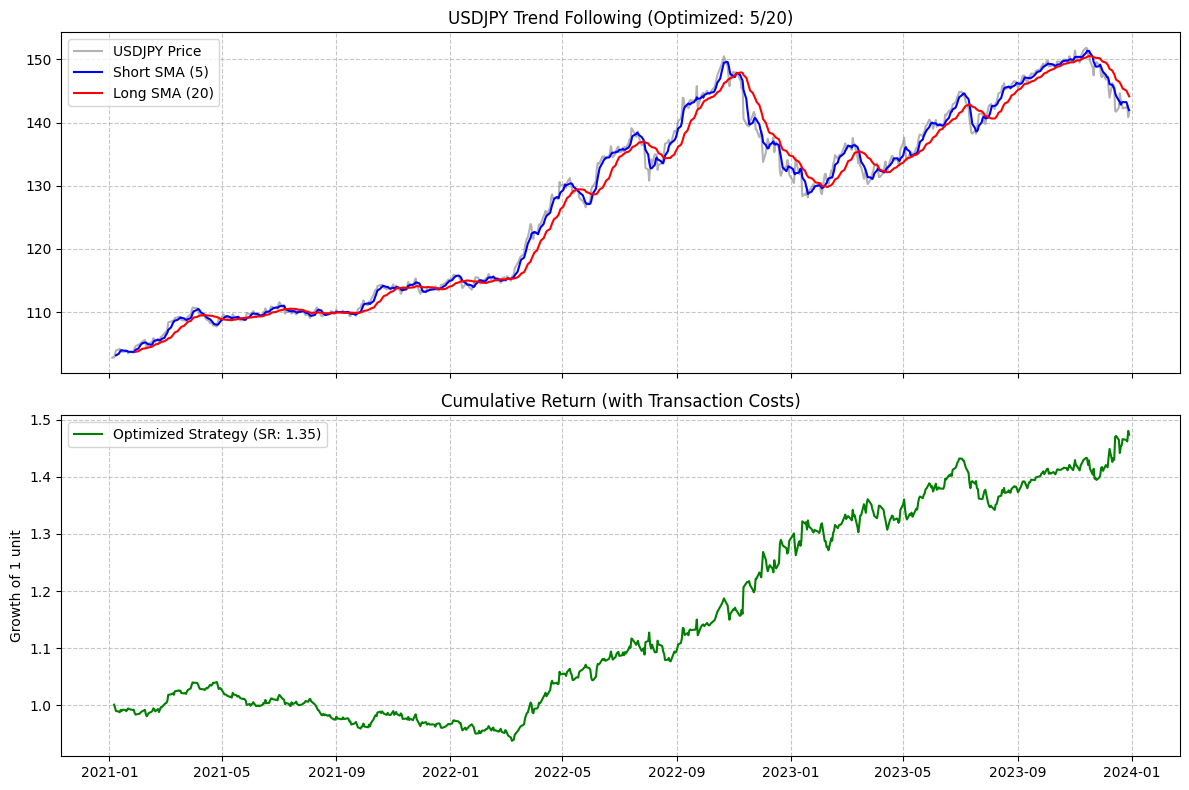

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# データの準備
if 'df' not in locals():
    df = pd.read_csv('/content/通貨データセット1.csv', index_col=0, parse_dates=True)
    df = df.select_dtypes(include=[np.number])
    returns_df = np.log(df / df.shift(1)).dropna()

asset = 'USDJPY'
price = df[asset]
actual_returns = returns_df[asset]

# 取引コスト
tc = 0.0005

# パラメータの探索範囲
short_windows = range(5, 55, 5)   # 5日から50日（5日刻み）
long_windows = range(20, 210, 10) # 20日から200日（10日刻み）

results = []

print(f"--- {asset} の移動平均クロスオーバー最適化を開始 ---")
for sw in short_windows:
    for lw in long_windows:
        if sw >= lw:
            continue

        sma_short = price.rolling(window=sw).mean()
        sma_long = price.rolling(window=lw).mean()

        # シグナル: 短期 > 長期 で 1 (買い)、それ以外は -1 (売り)
        signals = np.where(sma_short > sma_long, 1, -1)
        signals = pd.Series(signals, index=price.index)

        # ポジションの変更にかかるコスト
        turnover = signals.diff().abs()
        cost = turnover * tc

        # リターンの計算 (シグナルは1期遅らせて実際の収益率に乗算)
        gross_returns = signals.shift(1) * actual_returns
        strat_returns = (gross_returns - cost.shift(1)).dropna()

        # シャープレシオの計算
        if strat_returns.std() != 0:
            sr = (strat_returns.mean() / strat_returns.std()) * np.sqrt(252)
        else:
            sr = 0.0

        results.append({'Short': sw, 'Long': lw, 'Sharpe': sr})

# 結果をDataFrameに変換
results_df = pd.DataFrame(results)

# 最適パラメータの取得
best_params = results_df.loc[results_df['Sharpe'].idxmax()]
best_sw = int(best_params['Short'])
best_lw = int(best_params['Long'])
best_sr = best_params['Sharpe']

print(f"最適パラメータ: 短期SMA = {best_sw}日, 長期SMA = {best_lw}日")
print(f"最大年率シャープレシオ: {best_sr:.3f}")

# --- 最適パラメータでのバックテストとグラフ化 ---
sma_short_best = price.rolling(window=best_sw).mean()
sma_long_best = price.rolling(window=best_lw).mean()
signals_best = np.where(sma_short_best > sma_long_best, 1, -1)
signals_best = pd.Series(signals_best, index=price.index)

turnover_best = signals_best.diff().abs()
cost_best = turnover_best * tc
gross_returns_best = signals_best.shift(1) * actual_returns
strat_returns_best = (gross_returns_best - cost_best.shift(1)).dropna()

cum_returns_best = np.exp(strat_returns_best.cumsum())

# グラフ描画
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 価格と移動平均線
ax1.plot(price, label=f'{asset} Price', color='gray', alpha=0.6)
ax1.plot(sma_short_best, label=f'Short SMA ({best_sw})', color='blue')
ax1.plot(sma_long_best, label=f'Long SMA ({best_lw})', color='red')
ax1.set_title(f'{asset} Trend Following (Optimized: {best_sw}/{best_lw})')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 累積リターン
ax2.plot(cum_returns_best, label=f'Optimized Strategy (SR: {best_sr:.2f})', color='green')
ax2.set_title('Cumulative Return (with Transaction Costs)')
ax2.set_ylabel('Growth of 1 unit')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


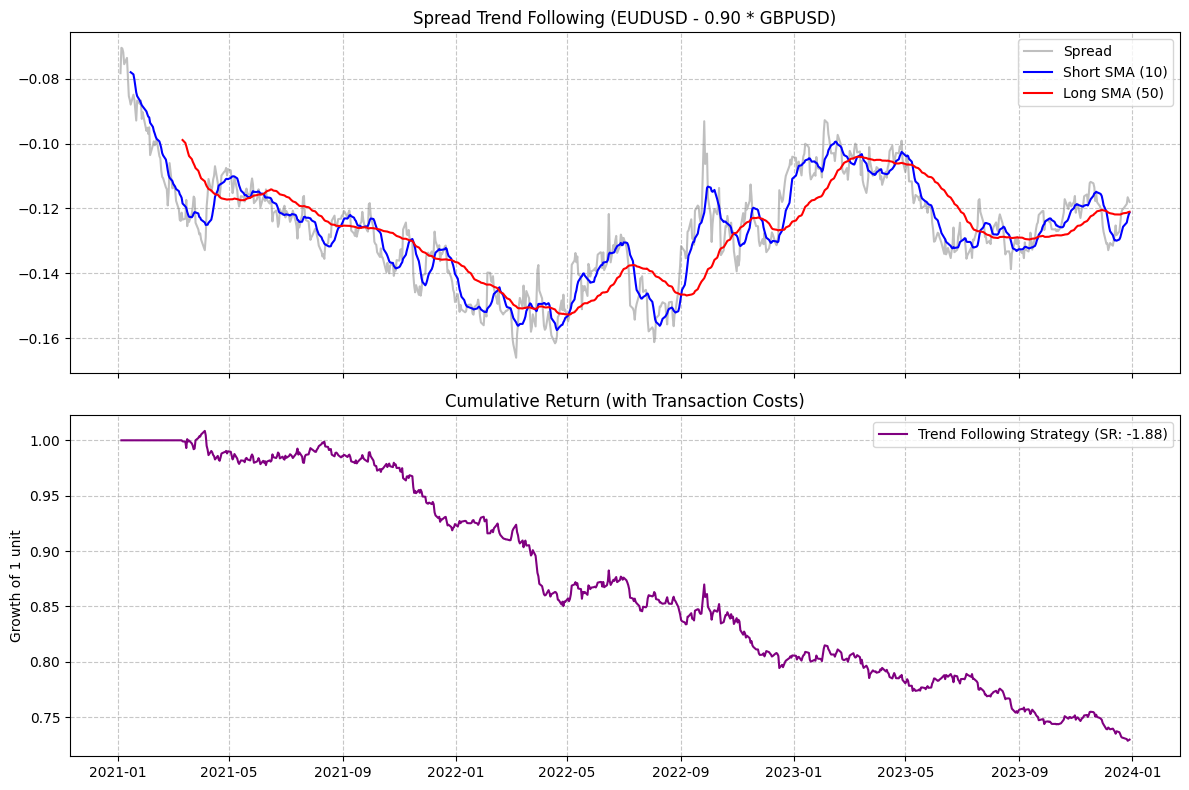

--- スプレッド・トレンドフォロー戦略の結果 ---
対象ペア: EUDUSD & GBPUSD
年率シャープレシオ: -1.877
最終累積リターン: -27.02%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# データの準備 (ロードされていない場合)
if 'df' not in locals():
    df = pd.read_csv('/content/通貨データセット1.csv', index_col=0, parse_dates=True)
    df = df.select_dtypes(include=[np.number])
    returns_df = np.log(df / df.shift(1)).dropna()

# ペアの設定 (共和分が最も強かったペアを使用)
asset1, asset2 = 'EUDUSD', 'GBPUSD'

y = np.log(df[asset1])
x = np.log(df[asset2])

# ヘッジ比率の計算
x_with_const = sm.add_constant(x)
model = sm.OLS(y, x_with_const).fit()
beta = model.params.iloc[1]

# スプレッドの計算
spread = y - beta * x

# --- スプレッドに対するトレンドフォロー戦略 (移動平均クロスオーバー) ---
short_window = 10
long_window = 50

spread_sma_short = spread.rolling(window=short_window).mean()
spread_sma_long = spread.rolling(window=long_window).mean()

# シグナル生成:
# 短期SMA > 長期SMA -> スプレッド拡大トレンド -> スプレッド買い (asset1買い, asset2売り) = 1
# 短期SMA < 長期SMA -> スプレッド縮小トレンド -> スプレッド売り (asset1売り, asset2買い) = -1
signals = pd.Series(index=spread.index, data=np.nan)
signals[spread_sma_short > spread_sma_long] = 1
signals[spread_sma_short < spread_sma_long] = -1
signals = signals.fillna(method='ffill').fillna(0) # シグナル継続、初期値0

# ポジションの割り当て
weight1 = signals
weight2 = -beta * signals

# リターンの計算 (取引コスト tc=0.0005 を考慮)
tc = 0.0005
gross_returns = weight1.shift(1) * returns_df[asset1] + weight2.shift(1) * returns_df[asset2]
cost = (weight1.diff().abs() + weight2.diff().abs()) * tc
strat_returns = (gross_returns - cost).dropna()

# 累積リターンとパフォーマンス
cum_returns = np.exp(strat_returns.cumsum())
annual_sr = (strat_returns.mean() / strat_returns.std()) * np.sqrt(252) if strat_returns.std() != 0 else 0

# グラフ描画
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# スプレッドと移動平均線
ax1.plot(spread, label='Spread', color='gray', alpha=0.5)
ax1.plot(spread_sma_short, label=f'Short SMA ({short_window})', color='blue')
ax1.plot(spread_sma_long, label=f'Long SMA ({long_window})', color='red')
ax1.set_title(f'Spread Trend Following ({asset1} - {beta:.2f} * {asset2})')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 累積リターン
ax2.plot(cum_returns, label=f'Trend Following Strategy (SR: {annual_sr:.2f})', color='purple')
ax2.set_title('Cumulative Return (with Transaction Costs)')
ax2.set_ylabel('Growth of 1 unit')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"--- スプレッド・トレンドフォロー戦略の結果 ---")
print(f"対象ペア: {asset1} & {asset2}")
print(f"年率シャープレシオ: {annual_sr:.3f}")
print(f"最終累積リターン: {(cum_returns.iloc[-1] - 1)*100:.2f}%")


In [ ]:
import pandas as pd
import numpy as np

# 共和分検定の結果(coint_df)の上位15ペアを表示
print("--- 共和分検定結果 トップ15 (p値が小さいほど平均回帰しやすい) ---")
display(coint_df.head(15))

--- 共和分検定結果 トップ15 (p値が小さいほど平均回帰しやすい) ---


,Asset1,Asset2,p_value
0,EUDUSD,GBPUSD,0.017176
1,AUDUSD,AUDJPY,0.027548
2,USDJPY,AUDJPY,0.027586
3,AUDJPY,GBPUSD,0.036806
4,USDJPY,AUDUSD,0.037811
5,EURJPY,AUDUSD,0.266286
6,EUDUSD,AUDJPY,0.302546
7,AUDUSD,EURGBP,0.374697
8,USDJPY,EURGBP,0.386548
9,AUDUSD,GBPUSD,0.507654


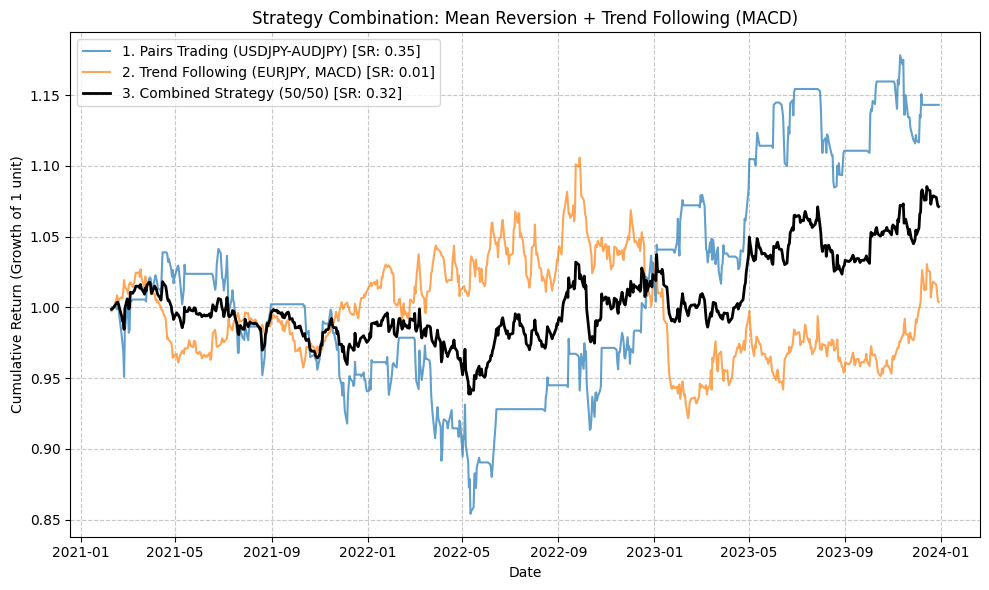

--- 戦略の相関 ---
ペアトレード(USDJPY-AUDJPY)とトレンドフォロー(MACD: EURJPY)の日次リターンの相関係数: -0.194


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 取引コストの設定
tc = 0.0005

# --- 1. ペアトレード戦略 (平均回帰) ---
# 銘柄を USDJPY と AUDJPY に変更
asset1_pt, asset2_pt = 'USDJPY', 'AUDJPY'
y = np.log(df[asset1_pt])
x = np.log(df[asset2_pt])
x_with_const = sm.add_constant(x)
model = sm.OLS(y, x_with_const).fit()
beta = model.params.iloc[1]

spread = y - beta * x
rolling_mean = spread.rolling(window=20).mean()
rolling_std = spread.rolling(window=20).std()
z_score = (spread - rolling_mean) / rolling_std

z_vals = z_score.fillna(0).values
sig_vals = np.zeros(len(z_vals))
pos = 0
entry_z = 2.0
for i in range(1, len(z_vals)):
    if z_vals[i-1] > entry_z: pos = -1
    elif z_vals[i-1] < -entry_z: pos = 1
    elif pos == -1 and z_vals[i-1] <= 0: pos = 0
    elif pos == 1 and z_vals[i-1] >= 0: pos = 0
    sig_vals[i] = pos

signals_pt = pd.Series(index=z_score.index, data=sig_vals)
weight1_pt = signals_pt
weight2_pt = -beta * signals_pt

gross_ret_pt = weight1_pt.shift(1) * returns_df[asset1_pt] + weight2_pt.shift(1) * returns_df[asset2_pt]
cost_pt = (weight1_pt.diff().abs() + weight2_pt.diff().abs()) * tc
ret_pairs = (gross_ret_pt - cost_pt).fillna(0)

# --- 2. トレンドフォロー戦略 (MACD) ---
asset_tf = 'EURJPY'
# MACDの計算 (Fast=12, Slow=26, Signal=9)
exp1 = df[asset_tf].ewm(span=12, adjust=False).mean()
exp2 = df[asset_tf].ewm(span=26, adjust=False).mean()
macd = exp1 - exp2
signal_line = macd.ewm(span=9, adjust=False).mean()

# MACDがシグナル線より上なら買い(+1)、下なら売り(-1)
signals_tf_vals = np.where(macd > signal_line, 1, -1)
signals_tf = pd.Series(index=df.index, data=signals_tf_vals)

gross_ret_tf = signals_tf.shift(1) * returns_df[asset_tf]
cost_tf = signals_tf.diff().abs() * tc
ret_trend = (gross_ret_tf - cost_tf).fillna(0)

# --- 3. 組み合わせ戦略 (資金を50%ずつ配分) ---
ret_combined = 0.5 * ret_pairs + 0.5 * ret_trend

# --- パフォーマンスの計算とグラフ化 ---
# MACDのSlow期間(26日)を除外して比較
valid_idx = ret_pairs.index[26:]
ret_pairs_eval = ret_pairs.loc[valid_idx]
ret_trend_eval = ret_trend.loc[valid_idx]
ret_combined_eval = ret_combined.loc[valid_idx]

def calc_cum_and_sr(ret_series):
    cum_ret = np.exp(ret_series.cumsum())
    sr = (ret_series.mean() / ret_series.std()) * np.sqrt(252) if ret_series.std() != 0 else 0
    return cum_ret, sr

cum_pt, sr_pt = calc_cum_and_sr(ret_pairs_eval)
cum_tf, sr_tf = calc_cum_and_sr(ret_trend_eval)
cum_cmb, sr_cmb = calc_cum_and_sr(ret_combined_eval)

plt.figure(figsize=(10, 6))
plt.plot(cum_pt, label=f'1. Pairs Trading ({asset1_pt}-{asset2_pt}) [SR: {sr_pt:.2f}]', alpha=0.7)
plt.plot(cum_tf, label=f'2. Trend Following ({asset_tf}, MACD) [SR: {sr_tf:.2f}]', alpha=0.7)
plt.plot(cum_cmb, label=f'3. Combined Strategy (50/50) [SR: {sr_cmb:.2f}]', color='black', linewidth=2)

plt.title('Strategy Combination: Mean Reversion + Trend Following (MACD)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Growth of 1 unit)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- 戦略の相関 ---")
print(f"ペアトレード({asset1_pt}-{asset2_pt})とトレンドフォロー(MACD: {asset_tf})の日次リターンの相関係数: {ret_pairs_eval.corr(ret_trend_eval):.3f}")

--- 共和分検定トップ5ペアのバックテスト結果 (取引コスト考慮, エントリーZ=2.5) ---
想定取引コスト: 1トレードあたり 0.05%
ペア: EUDUSD と GBPUSD | p値: 0.0172 | 年率SR: 0.203
ペア: AUDUSD と AUDJPY | p値: 0.0275 | 年率SR: 0.102
ペア: USDJPY と AUDJPY | p値: 0.0276 | 年率SR: 0.052
ペア: AUDJPY と GBPUSD | p値: 0.0368 | 年率SR: 0.219
ペア: USDJPY と AUDUSD | p値: 0.0378 | 年率SR: -0.373


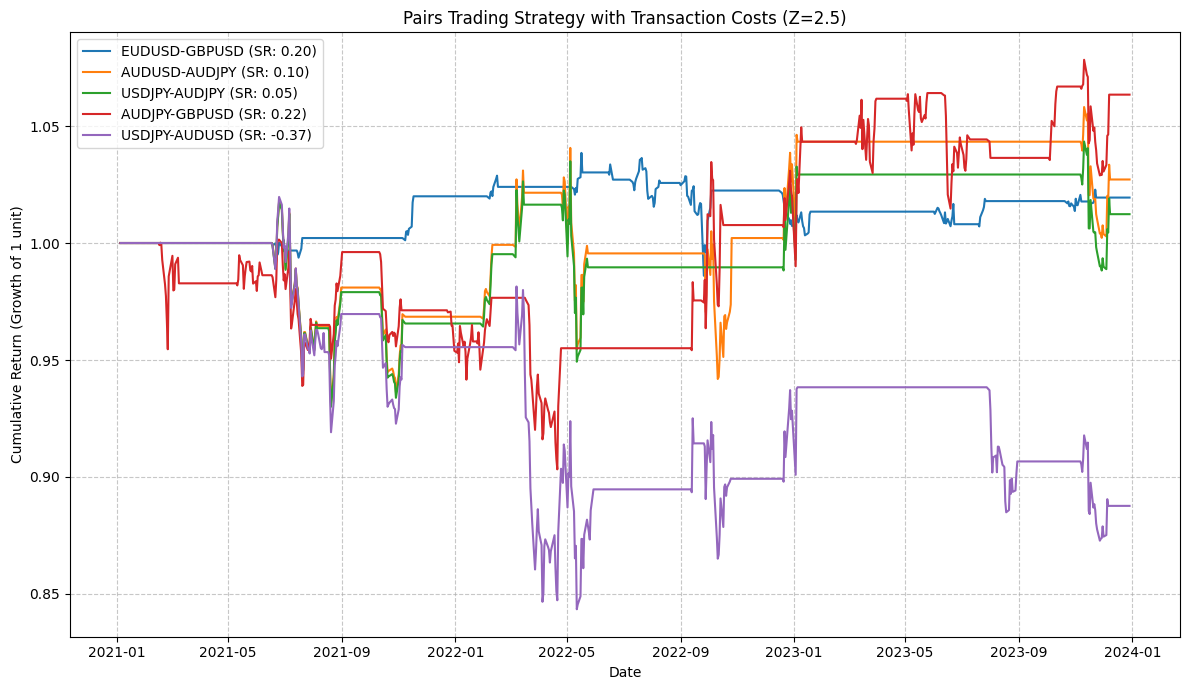

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 共和分検定の上位5ペアを取得
top_n = 5
pairs_to_test = coint_df.head(top_n)

# 取引コスト（スリッページや手数料）の設定 (例: 1取引あたり 0.05% = 0.0005)
tc = 0.0005

plt.figure(figsize=(12, 7))
print("--- 共和分検定トップ5ペアのバックテスト結果 (取引コスト考慮, エントリーZ=2.5) ---")
print(f"想定取引コスト: 1トレードあたり {tc*100:.2f}%")

for index, row in pairs_to_test.iterrows():
    asset1 = row['Asset1']
    asset2 = row['Asset2']
    p_val = row['p_value']

    y = np.log(df[asset1])
    x = np.log(df[asset2])

    # ヘッジ比率の計算
    x_with_const = sm.add_constant(x)
    model = sm.OLS(y, x_with_const).fit()
    beta = model.params.iloc[1]

    # スプレッドとZスコアの計算
    spread = y - beta * x
    window = 20
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    z_score = (spread - rolling_mean) / rolling_std

    # シグナルの生成
    z_vals = z_score.fillna(0).values
    sig_vals = np.zeros(len(z_vals))
    pos = 0
    entry_z = 2.5  # エントリー閾値を2.0から2.5に変更
    for i in range(1, len(z_vals)):
        if z_vals[i-1] > entry_z:
            pos = -1
        elif z_vals[i-1] < -entry_z:
            pos = 1
        elif pos == -1 and z_vals[i-1] <= 0:
            pos = 0
        elif pos == 1 and z_vals[i-1] >= 0:
            pos = 0
        sig_vals[i] = pos

    signals = pd.Series(index=z_score.index, data=sig_vals)

    # リターンの計算
    weight1 = signals
    weight2 = -beta * signals

    # グロス・リターン (コスト控除前)
    gross_returns = weight1.shift(1) * returns_df[asset1] + weight2.shift(1) * returns_df[asset2]

    # 取引コストの計算
    # ポジションが変化した時にコストが発生
    turnover1 = weight1.diff().abs()
    turnover2 = weight2.diff().abs()
    cost = (turnover1 + turnover2) * tc

    # ネット・リターン (コスト控除後)
    strat_returns = gross_returns - cost
    strat_returns = strat_returns.dropna()

    # 累積リターンとシャープレシオ
    cum_returns = np.exp(strat_returns.cumsum())
    if strat_returns.std() != 0:
        annual_sr = (strat_returns.mean() / strat_returns.std()) * np.sqrt(252)
    else:
        annual_sr = 0.0

    print(f"ペア: {asset1:6s} と {asset2:6s} | p値: {p_val:.4f} | 年率SR: {annual_sr:5.3f}")

    # グラフへのプロット
    plt.plot(cum_returns, label=f"{asset1}-{asset2} (SR: {annual_sr:.2f})")

plt.title('Pairs Trading Strategy with Transaction Costs (Z=2.5)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Growth of 1 unit)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- 共和分検定結果 トップ5 (p値が小さいほどスプレッドが平均回帰しやすい) ---


,Asset1,Asset2,p_value
0,EUDUSD,GBPUSD,0.017176
1,AUDUSD,AUDJPY,0.027548
2,USDJPY,AUDJPY,0.027586
3,AUDJPY,GBPUSD,0.036806
4,USDJPY,AUDUSD,0.037811



選ばれたペア (最もp値が小さい): EUDUSD と GBPUSD (p-value: 0.0172)


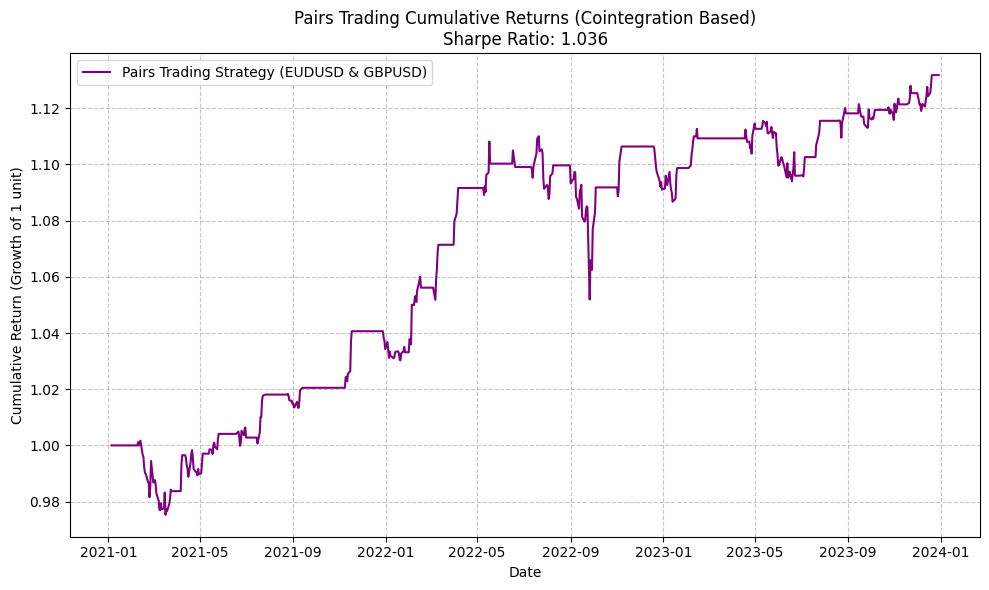

--- EUDUSD & GBPUSD のパフォーマンス ---
年率換算シャープレシオ: 1.036
最終リターン: 13.18%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import itertools
import warnings
warnings.filterwarnings('ignore')

# 1. データの読み込み
df = pd.read_csv('/content/通貨データセット1.csv', index_col=0, parse_dates=True)
df = df.select_dtypes(include=[np.number])
returns_df = np.log(df / df.shift(1)).dropna()

# 2. 全ペアの共和分検定 (Engle-Granger test)
assets = df.columns
pairs = list(itertools.combinations(assets, 2))
coint_results = []

for asset1, asset2 in pairs:
    y = np.log(df[asset1])
    x = np.log(df[asset2])
    # coint関数で検定 (帰無仮説：共和分関係がない)
    # p値が小さいほど、スプレッドが定常的（平均回帰的）であることを示す
    score, pvalue, _ = coint(y, x)
    coint_results.append((asset1, asset2, pvalue))

# p値でソート
coint_df = pd.DataFrame(coint_results, columns=['Asset1', 'Asset2', 'p_value'])
coint_df = coint_df.sort_values(by='p_value').reset_index(drop=True)
print("--- 共和分検定結果 トップ5 (p値が小さいほどスプレッドが平均回帰しやすい) ---")
display(coint_df.head(5))

# 3. 最も共和分関係の強いペアでバックテスト
best_pair = coint_df.iloc[0]
asset1, asset2 = best_pair['Asset1'], best_pair['Asset2']
print(f"\n選ばれたペア (最もp値が小さい): {asset1} と {asset2} (p-value: {best_pair['p_value']:.4f})")

# 対数価格
y = np.log(df[asset1])
x = np.log(df[asset2])

# ヘッジ比率(β)の計算
x_with_const = sm.add_constant(x)
model = sm.OLS(y, x_with_const).fit()
beta = model.params.iloc[1]

# スプレッドとZスコアの計算 (20日移動平均)
spread = y - beta * x
window = 20
rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()
z_score = (spread - rolling_mean) / rolling_std

# シグナル生成: Z > 2 で売り、Z < -2 で買い、0で手仕舞い
z_vals = z_score.fillna(0).values
sig_vals = np.zeros(len(z_vals))
pos = 0
entry_z = 2.0
for i in range(1, len(z_vals)):
    if z_vals[i-1] > entry_z:
        pos = -1
    elif z_vals[i-1] < -entry_z:
        pos = 1
    elif pos == -1 and z_vals[i-1] <= 0:
        pos = 0
    elif pos == 1 and z_vals[i-1] >= 0:
        pos = 0
    sig_vals[i] = pos

signals = pd.Series(index=z_score.index, data=sig_vals)

# リターンの計算
weight1 = signals
weight2 = -beta * signals
strat_returns = weight1.shift(1) * returns_df[asset1] + weight2.shift(1) * returns_df[asset2]
strat_returns = strat_returns.dropna()

# 累積リターンの計算
cum_returns = np.exp(strat_returns.cumsum())

# 4. パフォーマンスの評価とグラフ描画
daily_sr = strat_returns.mean() / strat_returns.std() if strat_returns.std() != 0 else 0
annual_sr = daily_sr * np.sqrt(252)

plt.figure(figsize=(10, 6))
plt.plot(cum_returns, label=f'Pairs Trading Strategy ({asset1} & {asset2})', color='purple')
plt.title(f'Pairs Trading Cumulative Returns (Cointegration Based)\nSharpe Ratio: {annual_sr:.3f}')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Growth of 1 unit)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"--- {asset1} & {asset2} のパフォーマンス ---")
print(f"年率換算シャープレシオ: {annual_sr:.3f}")
print(f"最終リターン: {(cum_returns.iloc[-1] - 1)*100:.2f}%")


--- トップ5ペアのバックテスト結果 ---
ペア: GBPUSD と EUDUSD | 相関係数:  0.764 | 年率SR: 0.762
ペア: AUDEUR と AUDUSD | 相関係数:  0.718 | 年率SR: 0.052
ペア: AUDJPY と EURJPY | 相関係数:  0.710 | 年率SR: 0.170
ペア: GBPUSD と AUDUSD | 相関係数:  0.709 | 年率SR: 0.043
ペア: AUDUSD と EUDUSD | 相関係数:  0.684 | 年率SR: -0.422


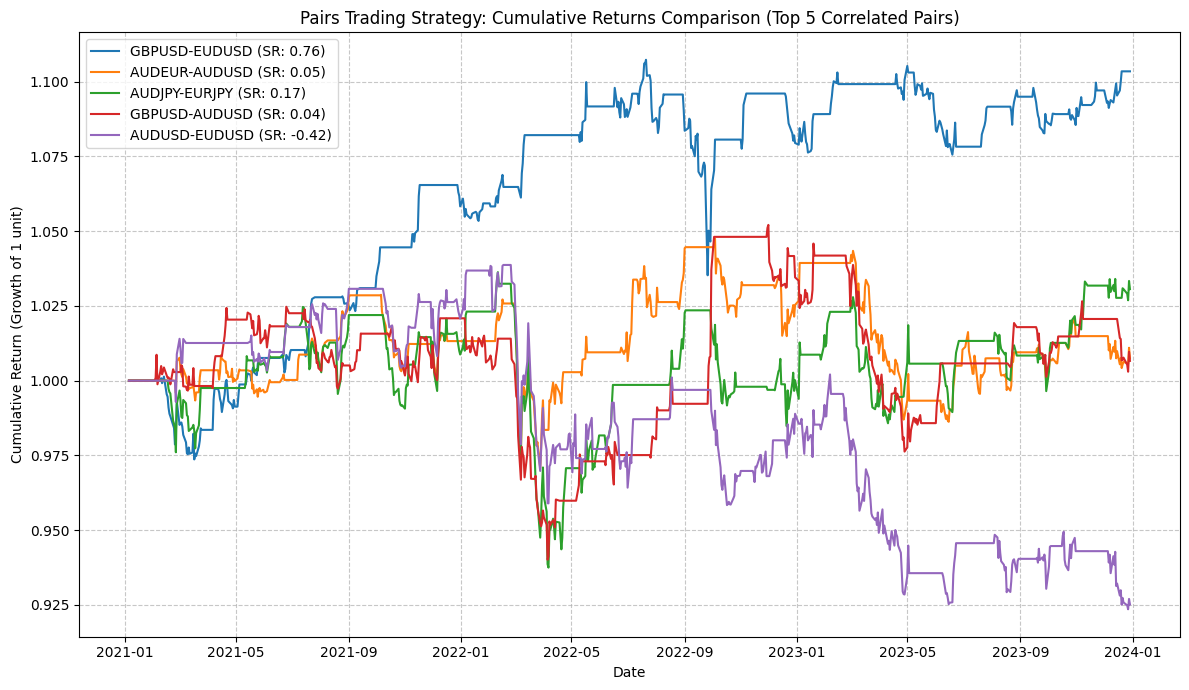

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# データが存在しない場合の読み込み
if 'df' not in locals():
    df = pd.read_csv('/content/通貨データセット1.csv', index_col=0, parse_dates=True)
    df = df.select_dtypes(include=[np.number])

returns_df = np.log(df / df.shift(1)).dropna()

# 相関行列の計算と、相関の高い上位5ペアの抽出
corr_matrix = returns_df.corr()
# 重複や対角成分（自身との相関=1）を排除
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
sorted_pairs = upper_tri.unstack().dropna().abs().sort_values(ascending=False)
top_n = 5
pairs_to_test = sorted_pairs.index[:top_n]

# ペアトレードのバックテストを関数化
def backtest_pair(asset1, asset2, df, returns_df, window=20, entry_z=2.0):
    y = np.log(df[asset1])
    x = np.log(df[asset2])

    # ヘッジ比率の計算
    x_with_const = sm.add_constant(x)
    model = sm.OLS(y, x_with_const).fit()
    beta = model.params.iloc[1]

    # スプレッドとZスコアの計算
    spread = y - beta * x
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    z_score = (spread - rolling_mean) / rolling_std

    # シグナルの生成 (高速化のためにNumPy配列を使用)
    z_vals = z_score.fillna(0).values
    sig_vals = np.zeros(len(z_vals))
    pos = 0
    for i in range(1, len(z_vals)):
        if z_vals[i-1] > entry_z:
            pos = -1
        elif z_vals[i-1] < -entry_z:
            pos = 1
        elif pos == -1 and z_vals[i-1] <= 0:
            pos = 0
        elif pos == 1 and z_vals[i-1] >= 0:
            pos = 0
        sig_vals[i] = pos

    signals = pd.Series(index=z_score.index, data=sig_vals)

    # リターンの計算
    weight1 = signals
    weight2 = -beta * signals
    strat_returns = weight1.shift(1) * returns_df[asset1] + weight2.shift(1) * returns_df[asset2]
    strat_returns = strat_returns.dropna()

    # 累積リターンとシャープレシオ
    cum_returns = np.exp(strat_returns.cumsum())

    if strat_returns.std() != 0:
        annual_sr = (strat_returns.mean() / strat_returns.std()) * np.sqrt(252)
    else:
        annual_sr = 0.0

    return cum_returns, annual_sr

# バックテストの実行とグラフ描画
plt.figure(figsize=(12, 7))
print("--- トップ5ペアのバックテスト結果 ---")

for asset1, asset2 in pairs_to_test:
    cum_ret, sr = backtest_pair(asset1, asset2, df, returns_df)
    # 元の相関係数（絶対値ではなく実際の符号）を取得
    corr_val = corr_matrix.loc[asset1, asset2]

    print(f"ペア: {asset1:6s} と {asset2:6s} | 相関係数: {corr_val:6.3f} | 年率SR: {sr:5.3f}")

    label = f"{asset1}-{asset2} (SR: {sr:.2f})"
    plt.plot(cum_ret, label=label)

plt.title('Pairs Trading Strategy: Cumulative Returns Comparison (Top 5 Correlated Pairs)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Growth of 1 unit)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


選ばれたペア: EUDUSD と GBPUSD (相関係数: 0.764)
ヘッジ比率 (beta): 0.904


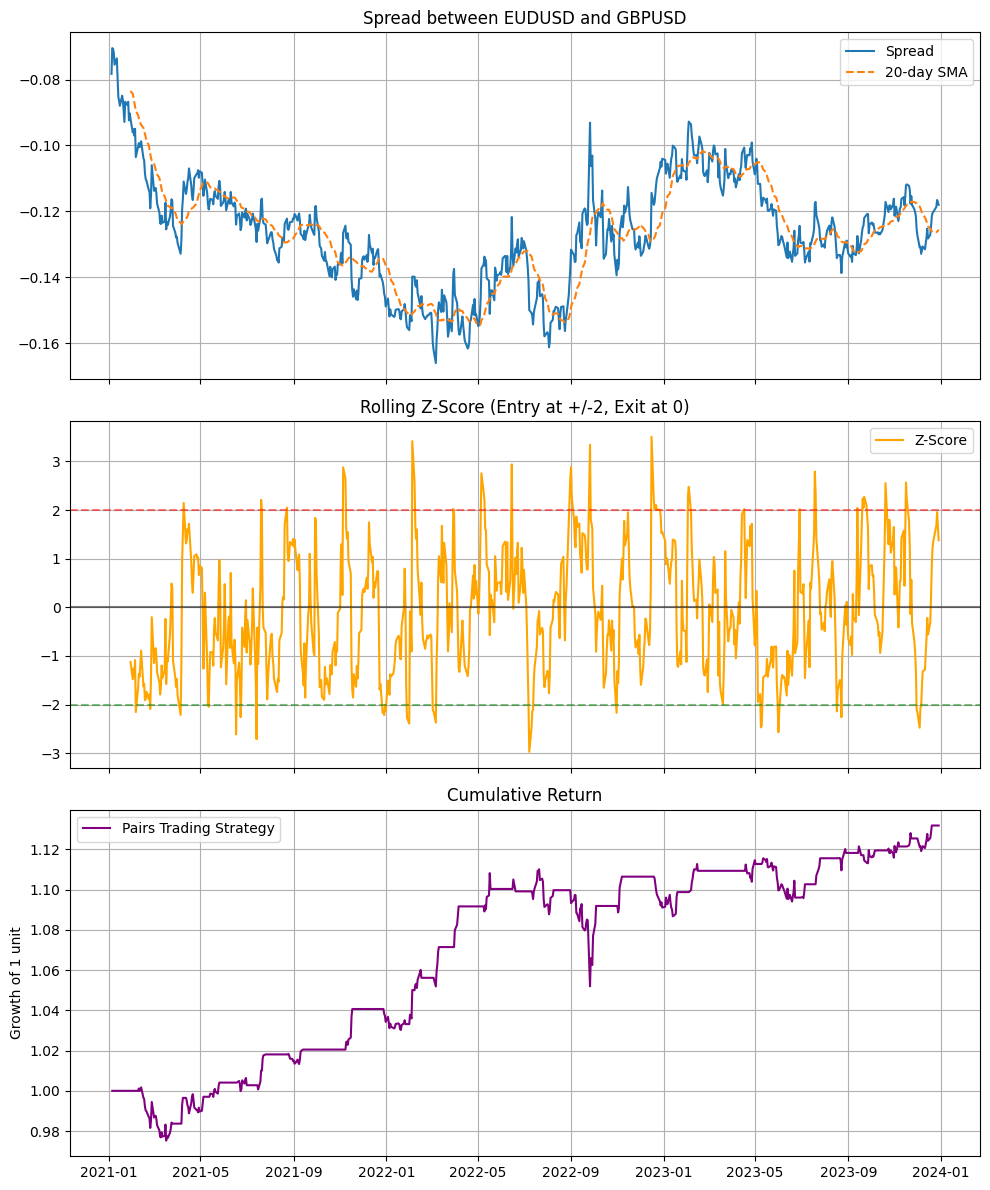

--- パフォーマンス ---
1期あたり平均リターン: 0.000160
1期あたりリスク(標準偏差): 0.002454
年率換算シャープレシオ: 1.036


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# データがロードされていない場合の対策
if 'df' not in locals():
    df = pd.read_csv('/content/通貨データセット1.csv', index_col=0, parse_dates=True)
    df = df.select_dtypes(include=[np.number])

# リターンの計算と最も相関の高いペアの探索
returns_df = np.log(df / df.shift(1)).dropna()
corr_matrix = returns_df.corr()
np.fill_diagonal(corr_matrix.values, 0)
pair = corr_matrix.abs().unstack().idxmax()
asset1, asset2 = pair

print(f"選ばれたペア: {asset1} と {asset2} (相関係数: {corr_matrix.loc[asset1, asset2]:.3f})")

# 対数価格の取得
y = np.log(df[asset1])
x = np.log(df[asset2])

# OLS（最小二乗法）によるヘッジ比率（beta）の算出（全期間簡易版）
x_with_const = sm.add_constant(x)
model = sm.OLS(y, x_with_const).fit()
beta = model.params.iloc[1]
print(f"ヘッジ比率 (beta): {beta:.3f}")

# スプレッドの計算
spread = y - beta * x

# Zスコアの計算 (20日移動平均)
window = 20
rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()
z_score = (spread - rolling_mean) / rolling_std

# シグナルの生成
# Z > 2 でスプレッド売り (asset1売り, asset2買い)
# Z < -2 でスプレッド買い (asset1買い, asset2売り)
# Zの符号が反転（0をまたぐ）で手仕舞い

signals = pd.Series(index=z_score.index, data=0.0)
position = 0

for i in range(1, len(z_score)):
    if z_score.iloc[i-1] > 2.0:
        position = -1
    elif z_score.iloc[i-1] < -2.0:
        position = 1
    elif position == -1 and z_score.iloc[i-1] <= 0:
        position = 0
    elif position == 1 and z_score.iloc[i-1] >= 0:
        position = 0

    signals.iloc[i] = position

# ポジションの割り当て (1期遅らせてリターンを計算)
weight1 = signals
weight2 = -beta * signals

# 戦略リターンの計算
strat_returns = weight1.shift(1) * returns_df[asset1] + weight2.shift(1) * returns_df[asset2]
strat_returns = strat_returns.dropna()

# 累積リターン (対数リターンのため exp を使用)
cum_returns = np.exp(strat_returns.cumsum())

# グラフの描画
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# スプレッド
ax1.plot(spread, label='Spread')
ax1.plot(rolling_mean, label='20-day SMA', linestyle='--')
ax1.set_title(f'Spread between {asset1} and {asset2}')
ax1.legend()
ax1.grid(True)

# Zスコア
ax2.plot(z_score, label='Z-Score', color='orange')
ax2.axhline(2, color='red', linestyle='--', alpha=0.5)
ax2.axhline(-2, color='green', linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linestyle='-', alpha=0.5)
ax2.set_title('Rolling Z-Score (Entry at +/-2, Exit at 0)')
ax2.legend()
ax2.grid(True)

# 累積リターン
ax3.plot(cum_returns, label='Pairs Trading Strategy', color='purple')
ax3.set_title('Cumulative Return')
ax3.set_ylabel('Growth of 1 unit')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

# パフォーマンスのサマリー
daily_sr = strat_returns.mean() / strat_returns.std()
annual_sr = daily_sr * np.sqrt(252)
print(f"--- パフォーマンス ---")
print(f"1期あたり平均リターン: {strat_returns.mean():.6f}")
print(f"1期あたりリスク(標準偏差): {strat_returns.std():.6f}")
print(f"年率換算シャープレシオ: {annual_sr:.3f}")


--- Alphaごとのシャープレシオ ---
Alpha: 0.001 -> Sharpe Ratio: 0.003368
Alpha: 0.005 -> Sharpe Ratio: 0.003368
Alpha: 0.010 -> Sharpe Ratio: 0.003368
Alpha: 0.020 -> Sharpe Ratio: 0.003368
Alpha: 0.050 -> Sharpe Ratio: 0.003368
Alpha: 0.100 -> Sharpe Ratio: 0.003368
Alpha: 0.200 -> Sharpe Ratio: 0.003368
Alpha: 0.500 -> Sharpe Ratio: 0.003368


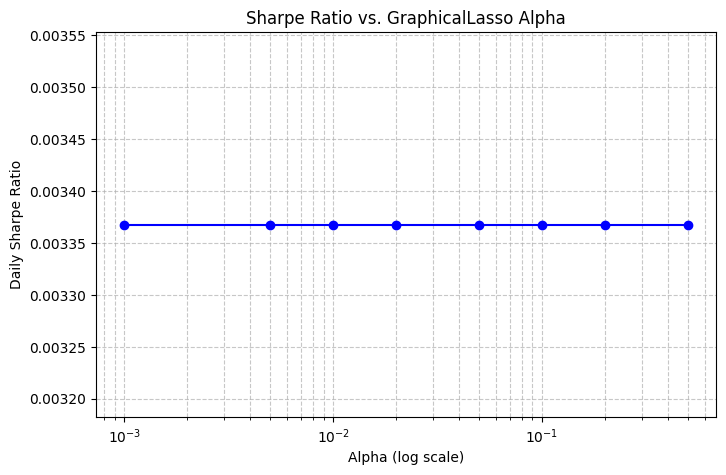

In [ ]:
import pandas as pd
import numpy as np
from sklearn.covariance import GraphicalLasso
from scipy.linalg import fractional_matrix_power
import matplotlib.pyplot as plt

# 検証するalphaのリスト（対数スケール的に配置）
alphas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
sharpe_ratios = []

print("--- Alphaごとのシャープレシオ ---")
for alpha in alphas:
    try:
        # GGMによる無相関化
        gl = GraphicalLasso(alpha=alpha, max_iter=100)
        gl.fit(pca_residuals)
        inv_sqrt_cov = fractional_matrix_power(gl.precision_, 0.5)
        ggm_res = pd.DataFrame(
            np.dot(pca_residuals.values, inv_sqrt_cov),
            index=returns.index,
            columns=returns.columns
        )

        # リバーサル戦略の計算
        signal = -(ggm_res.sub(ggm_res.mean(axis=1), axis=0))
        weight = signal.div(signal.abs().sum(axis=1), axis=0)
        strat_ret = (weight.shift(1) * returns).sum(axis=1)

        # 日次シャープレシオの計算
        sharpe = strat_ret.mean() / strat_ret.std()
        sharpe_ratios.append(sharpe)
        print(f"Alpha: {alpha:5.3f} -> Sharpe Ratio: {sharpe:.6f}")

    except Exception as e:
        print(f"Alpha: {alpha:5.3f} -> Error: {e}")
        sharpe_ratios.append(np.nan)

# グラフでの可視化
plt.figure(figsize=(8, 5))
plt.plot(alphas, sharpe_ratios, marker='o', linestyle='-', color='b')
plt.xscale('log') # alphaは対数スケールが見やすい
plt.title('Sharpe Ratio vs. GraphicalLasso Alpha')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Daily Sharpe Ratio')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.show()


,USDJPY,EURJPY,EUDUSD,AUDUSD,AUDJPY,AUDEUR,GBPUSD,EURGBP
2021-01-04,102.805,126.27,1.22825,0.77345,79.515,0.6297,1.36910,0.89712
2021-01-05,102.915,126.31,1.22735,0.77115,79.363,0.6283,1.35620,0.90499
2021-01-06,102.825,126.74,1.23255,0.77895,80.096,0.6320,1.36290,0.90436
2021-01-07,103.385,127.12,1.22955,0.77755,80.387,0.6324,1.36095,0.90345
2021-01-08,103.965,127.11,1.22255,0.77655,80.734,0.6352,1.35790,0.90032


データを価格とみなし、対数収益率(log returns)に変換しました。
データサイズ: (773, 8)


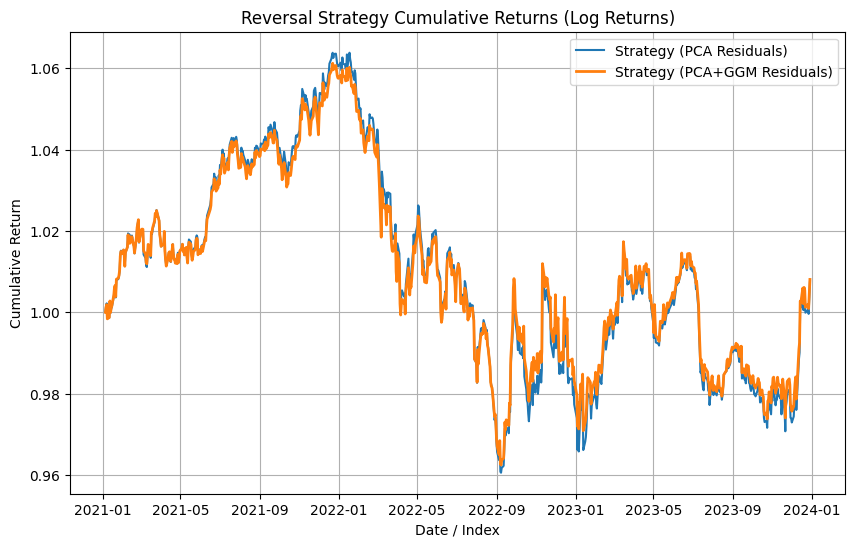

--- パフォーマンス (1期あたりの平均/標準偏差) ---
PCA残差戦略    : Return 0.000010, Risk 0.003200, Sharpe 0.0030
PCA+GGM残差戦略: Return 0.000010, Risk 0.003084, Sharpe 0.0034


In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.covariance import GraphicalLasso
from scipy.linalg import fractional_matrix_power
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. データの読み込み
file_path = '/content/通貨データセット1.csv'
try:
    # インデックスを最初の列（日付などを想定）に設定
    df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    display(df.head())

    # 数値データのみを抽出
    df = df.select_dtypes(include=[np.number])

    # 価格データかリターンデータかを簡易的に判定し、必要ならリターンに変換
    if df.max().max() > 1.5:  # 最大値が1.5より大きい場合は価格とみなして変化率をとる
        # 対数収益率 (log returns) に変更
        returns = np.log(df / df.shift(1)).dropna()
        print("データを価格とみなし、対数収益率(log returns)に変換しました。")
    else:
        returns = df.dropna()
        print("データを収益率としてそのまま使用します。")

    print(f"データサイズ: {returns.shape}")

    # 2. PCAとGGMによる残差抽出 (全期間一括簡易版)
    # PCAによる第一主成分(共通ファクター)の除去
    pca = PCA(n_components=1)
    market_comp = pca.fit_transform(returns)
    reconstructed = pca.inverse_transform(market_comp)
    pca_residuals = returns - reconstructed

    # GGMによる無相関化
    gl = GraphicalLasso(alpha=0.01, max_iter=100)
    gl.fit(pca_residuals)
    inv_sqrt_cov = fractional_matrix_power(gl.precision_, 0.5)
    ggm_residuals = pd.DataFrame(
        np.dot(pca_residuals.values, inv_sqrt_cov),
        index=returns.index,
        columns=returns.columns
    )

    # 3. リバーサル戦略の構築
    # 前期の残差リターンを基にウェイトを決定（低いものを買い、高いものを売る）
    def calc_reversal_returns(residuals, actual_returns):
        # クロスセクションで平均を引き、マーケットニュートラルなシグナルにする (-1 を掛けてリバーサル)
        signal = -(residuals.sub(residuals.mean(axis=1), axis=0))
        # 絶対値の和で割ることで、各期の総エクスポージャーを1（Long 0.5, Short 0.5）に正規化
        weight = signal.div(signal.abs().sum(axis=1), axis=0)
        # 1期遅らせて(シフトして)実際の収益率に掛ける
        strat_returns = (weight.shift(1) * actual_returns).sum(axis=1)
        return strat_returns

    strat_ret_pca = calc_reversal_returns(pca_residuals, returns)
    strat_ret_ggm = calc_reversal_returns(ggm_residuals, returns)

    # 4. パフォーマンスの可視化
    # 対数リターンのため、累積リターンは指数関数(exp)と累積和(cumsum)で計算
    cum_ret_pca = np.exp(strat_ret_pca.cumsum())
    cum_ret_ggm = np.exp(strat_ret_ggm.cumsum())

    plt.figure(figsize=(10, 6))
    plt.plot(cum_ret_pca, label='Strategy (PCA Residuals)')
    plt.plot(cum_ret_ggm, label='Strategy (PCA+GGM Residuals)', linewidth=2)
    plt.title('Reversal Strategy Cumulative Returns (Log Returns)')
    plt.xlabel('Date / Index')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.grid(True)
    plt.show()

    # シャープレシオの簡易計算
    print("--- パフォーマンス (1期あたりの平均/標準偏差) ---")
    print(f"PCA残差戦略    : Return {strat_ret_pca.mean():.6f}, Risk {strat_ret_pca.std():.6f}, Sharpe {strat_ret_pca.mean()/strat_ret_pca.std():.4f}")
    print(f"PCA+GGM残差戦略: Return {strat_ret_ggm.mean():.6f}, Risk {strat_ret_ggm.std():.6f}, Sharpe {strat_ret_ggm.mean()/strat_ret_ggm.std():.4f}")

except Exception as e:
    print(f"エラーが発生しました: {e}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.covariance import GraphicalLasso
from scipy.linalg import fractional_matrix_power
import matplotlib.pyplot as plt

# 1. ダミーデータの生成 (例: 200日分、50銘柄)
np.random.seed(42)
n_samples = 200
n_features = 50

# 市場共通ファクターと固有のノイズからなる収益率をシミュレーション
market_factor = np.random.normal(0, 0.01, n_samples)
returns = np.random.normal(0, 0.005, (n_samples, n_features))
for i in range(n_features):
    returns[:, i] += market_factor * np.random.uniform(0.5, 1.5)

df_returns = pd.DataFrame(returns)

# 2. PCAによる主成分（市場共通リスク）の抽出と除去
# 論文の趣旨に基づき、第一主成分（市場ファクター）を取り除く
pca = PCA(n_components=1)
pca.fit(df_returns)
market_components = pca.transform(df_returns)
reconstructed_market = pca.inverse_transform(market_components)

# PCA残差リターン（共通ファクター除去後）
pca_residuals = df_returns - reconstructed_market

# 3. GGM（ガウス型グラフィカルモデル）による残差抽出
# Graphical Lassoを用いて、変数間のスパースな精度行列（逆共分散行列）を推定
gl = GraphicalLasso(alpha=0.01, max_iter=100)
gl.fit(pca_residuals)

# 精度行列 (Precision matrix)
precision_matrix = gl.precision_

# 精度行列(逆共分散)の平方根行列を掛けることで無相関化（GGM残差）
inv_sqrt_cov = fractional_matrix_power(precision_matrix, 0.5)
ggm_residuals = np.dot(pca_residuals.values, inv_sqrt_cov)

# 4. 結果の確認（各段階での直交性・無相関性の比較）
def get_off_diagonal_mean(matrix):
    corr = np.corrcoef(matrix, rowvar=False)
    # 対角成分（1.0）以外の絶対値の平均を取得
    np.fill_diagonal(corr, 0)
    return np.mean(np.abs(corr))

print("元の収益率の非対角相関の平均:", get_off_diagonal_mean(df_returns.values))
print("PCA残差の非対角相関の平均:", get_off_diagonal_mean(pca_residuals.values))
print("PCA+GGM残差の非対角相関の平均:", get_off_diagonal_mean(ggm_residuals))

元の収益率の非対角相関の平均: 0.7353893887503269
PCA残差の非対角相関の平均: 0.05846480987227385
PCA+GGM残差の非対角相関の平均: 0.05846480987227385


In [ ]:
!pip install -q PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 67.3 MB/s eta 0:00:00


In [ ]:
import fitz  # PyMuPDF

pdf_path = '/content/2026_264.pdf'
doc = fitz.open(pdf_path)

# 最初の数ページを読み込んで内容を確認します
text = ""
for i in range(min(3, len(doc))):
    page = doc.load_page(i)
    text += page.get_text() + "\n"

print(text[:1500])  # 最初の1500文字を表示

主成分分析とガウス型グラフィカルモデルによる
残差リターンの抽出とモメンタム戦略への応用
Extracting Residual Returns via Principal Component Analysis and
Gaussian Graphical Models for a Momentum Strategy
渡部航史1
尾崎令拓2
今城健太郎2
平野正徳2
Koshi Watanabe
Ryota Ozaki
Kentaro Imajo
Masanori Hirano
1 北海道大学大学院情報科学院
2 株式会社Preferred Networks
Abstract:
市場全体のリスクをヘッジする取引戦略において残差リターンが有効であることが知られている．
残差リターンの特定には多変量解析手法が用いられるが，金融時系列において頻繁に発生するランク落ちなど
の不安定性が大きな課題となる．本論文では，主成分分析とガウス型グラフィカルモデルを組み合わせて残差
要因を抽出する方法を提案する．提案手法によって得られた残差リターンは，広く用いられている主成分分析
ベースの手法から得られるものと比較して，高い安定性と直交性を示すことを確認した．さらに，S&P500 お
よびTOPIX500 構成銘柄の過去データを用いたバックテストでは，残差リターンの直交性が向上し，リバーサ
ル戦略におけるシャープレシオが改善することを確認した．
1
はじめに
金融資産の値動きから各資産に固有の変動である残
渣リターンを抽出する試みは古くから注目を集めてき
た．例えば，資産の値動きのモデル化に用いられるファ
クターモデルでは，市場に共通する変動と各資産に固
有の変動に分解する[15, 6]．得られたファクターモデ
ルを用いることで適切な投資のリスク分散やパフォー
マンス分析が可能となり，実務においても標準的な枠
組みとして用いられている．近年の研究では，残渣リ
ターンは市場にヘッジしたポートフォリオの構築に有
効であることが報告されており[3, 9]，残渣リターンを
正確に抜き出すことは取引戦略の選択に有効であると
期待される．
残渣リターンを抜き出すために，主成分分析により
得られる主要な主成分を情報量基準等により取り除く
手法が研究されてきた[2, 7]．この枠組みでは，各ファ
クタ